Згенерований набір даних:

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  Target
0   0.351385   2.182377  -0.255875  -0.388255   0.892724  -0.868436       1
1  -1.800301   0.169075   1.640729  -1.884878   2.475151   0.236966       0
2  -0.907700   1.365479  -1.349986  -0.732752   1.534017  -1.771557       1
3   1.168221  -2.001491  -0.103807   1.528139  -2.402107   2.811396       1
4  -0.869636   1.487769  -1.373556  -1.545475   2.116369  -1.050364       1 

Точність моделі: 0.9

Звіт по метриках моделі:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       100
           1       0.89      0.91      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



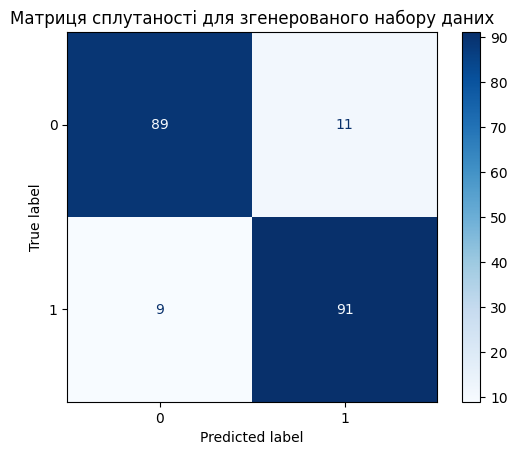

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

X, y = make_classification(
    n_samples=1000,       
    n_features=6,          
    n_informative=4,       
    n_redundant=1,        
    n_classes=2,           
    random_state=42
)

columns = [f"Feature_{i}" for i in range(1, 7)]
df = pd.DataFrame(X, columns=columns)
df["Target"] = y

print("Згенерований набір даних:\n")
print(df.head(), "\n")


X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_s, y_train)


y_pred = clf.predict(X_test_s)

print("Точність моделі:", accuracy_score(y_test, y_pred))
print("\nЗвіт по метриках моделі:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Матриця сплутаності для згенерованого набору даних")
plt.show()


